# Implementing a GPT model from scratch

## Coding LLM architecture

In [1]:
GPT_CONFIG_124M = {
    "vocab_size": 50257,
    "context_length": 1024, # Max number of input tokens the model can handle via the positional embeddings
    "emb_dim": 768, # embedding size
    "n_heads": 12, # number of attention heads
    "n_layers": 12, # Number of transformer blocks
    "drop_rate": 0.1, # Dropout rate, to prevent overfitting
    "qkv_bias": False
}
    

We start by making a placeholder GPT model architecture class

In [2]:
import torch
import torch.nn as nn

class DummyGPTModel(nn.Module):
    def __init__(self, cfg):
        super().__init__()
        self.tok_emb = nn.Embedding(cfg["vocab_size"], cfg["emb_dim"])
        self.pos_emb = nn.Embedding(cfg["context_length"], cfg["emb_dim"])
        self.drop_emb = nn.Dropout(cfg["drop_rate"])

        # Placeholder TransformerBlock
        self.trf_blocks = nn.Sequential(
            *[DummyTransformerBlock(cfg)
              for _ in range(cfg["n_layers"])]
        )

        # Placeholder LayerNorm
        self.final_norm = DummyLayerNorm(cfg["emb_dim"])
        self.out_head = nn.Linear(
            cfg["emb_dim"], cfg["vocab_size"], bias=False
        )

    # data flow through model
    def forward(self, in_idx):
        # Create embeddings
        batch_size, seq_len = in_idx.shape
        tok_embeds = self.tok_emb(in_idx)
        pos_embeds = self.pos_emb(
            torch.arange(seq_len, device=in_idx.device)
        )
        x = tok_embeds + pos_embeds
        x = self.drop_emb(x) # Apply dropout
        x = self.trf_blocks(x) # Create transformer blocks
        x = self.final_norm(x) # Final layer normalization
        logits = self.out_head(x) # Output layer
        return logits

# Placeholder class that will be replaced by a real TransformerBlock later
class DummyTransformerBlock(nn.Module):
    def __init__(self, cfg):
        super().__init__()

    def forward(self, x):
        return x

# Placeholder class that will be replaced by a real LayerNorm later
class DummyLayerNorm(nn.Module):
    def __init__(self, normailzed_shape, eps=1e-5):
        super().__init__()

    def forward(self, x):
        return x

In [3]:
import tiktoken

tokenizer = tiktoken.get_encoding("gpt2")
batch = []
txt1 = "Every effort moves you"
txt2 = "Every day holds a"

batch.append(torch.tensor(tokenizer.encode(txt1)))
batch.append(torch.tensor(tokenizer.encode(txt2)))
batch = torch.stack(batch, dim=0)
print(batch)

tensor([[6109, 3626, 6100,  345],
        [6109, 1110, 6622,  257]])


In [4]:
torch.manual_seed(123)
model = DummyGPTModel(GPT_CONFIG_124M)
logits = model(batch) # Logits are the outputs
print("Output shape:", logits.shape)
print(logits)

Output shape: torch.Size([2, 4, 50257])
tensor([[[-1.2034,  0.3201, -0.7130,  ..., -1.5548, -0.2390, -0.4667],
         [-0.1192,  0.4539, -0.4432,  ...,  0.2392,  1.3469,  1.2430],
         [ 0.5307,  1.6720, -0.4695,  ...,  1.1966,  0.0111,  0.5835],
         [ 0.0139,  1.6754, -0.3388,  ...,  1.1586, -0.0435, -1.0400]],

        [[-1.0908,  0.1798, -0.9484,  ..., -1.6047,  0.2439, -0.4530],
         [-0.7860,  0.5581, -0.0610,  ...,  0.4835, -0.0077,  1.6621],
         [ 0.3567,  1.2698, -0.6398,  ..., -0.0162, -0.1296,  0.3717],
         [-0.2407, -0.7349, -0.5102,  ...,  2.0057, -0.3694,  0.1814]]],
       grad_fn=<UnsafeViewBackward0>)


## Normalizing activations with layer normalization

To ensure stability and efficiency in the neural network training, we will implement layer normalization.  Layer normalization adjusts the activations(outputs) of a neural network layer to have a mean of 0 and variance of 1(unit variance).

In GPT-2 and modern transformer architectures, layer normalization is typically applied before and after the multi-head attention module, and before the final output layer.

In [5]:
# Layer normalization example
torch.manual_seed(123)
batch_example = torch.randn(2, 5) # Creates two training examples with five dimensions(features) each
layer = nn.Sequential(nn.Linear(5, 6), nn.ReLU())
out = layer(batch_example)
print(out)

tensor([[0.2260, 0.3470, 0.0000, 0.2216, 0.0000, 0.0000],
        [0.2133, 0.2394, 0.0000, 0.5198, 0.3297, 0.0000]],
       grad_fn=<ReluBackward0>)


In [6]:
mean = out.mean(dim=-1, keepdim=True)
var = out.var(dim=-1, keepdim=True)
print("Mean:\n", mean)
print("Variance:\n", var)

Mean:
 tensor([[0.1324],
        [0.2170]], grad_fn=<MeanBackward1>)
Variance:
 tensor([[0.0231],
        [0.0398]], grad_fn=<VarBackward0>)


In [7]:
# Aply the layer normalization
out_norm = (out - mean) / torch.sqrt(var)
mean = out_norm.mean(dim=-1, keepdim=True)
var = out_norm.var(dim=-1, keepdim=True)
print("Normalized layer outputs:\n", out_norm)
print("Mean:\n", mean)
print("Variance:\n", var)

Normalized layer outputs:
 tensor([[ 0.6159,  1.4126, -0.8719,  0.5872, -0.8719, -0.8719],
        [-0.0189,  0.1121, -1.0876,  1.5173,  0.5647, -1.0876]],
       grad_fn=<DivBackward0>)
Mean:
 tensor([[-5.9605e-08],
        [ 1.9868e-08]], grad_fn=<MeanBackward1>)
Variance:
 tensor([[1.0000],
        [1.0000]], grad_fn=<VarBackward0>)


In [8]:
torch.set_printoptions(sci_mode=False)
print("Mean:\n", mean)
print("Variance:\n", var)

Mean:
 tensor([[-0.0000],
        [ 0.0000]], grad_fn=<MeanBackward1>)
Variance:
 tensor([[1.0000],
        [1.0000]], grad_fn=<VarBackward0>)


## Create the LayerNorm class

In [9]:
class LayerNorm(nn.Module):
    def __init__(self, emb_dim):
        super().__init__()
        self.eps = 1e-5
        # Scale and Shift are trainable parameters that the LLM automatically adjust during training
        # if it determines it would improve performance
        self.scale = nn.Parameter(torch.ones(emb_dim))
        self.shift = nn.Parameter(torch.zeros(emb_dim))

    def forward(self, x):
        mean = x.mean(dim=-1, keepdim=True)
        var = x.var(dim=-1, keepdim=True, unbiased=False)
        norm_x = (x - mean) / torch.sqrt(var + self.eps)
        return self.scale * norm_x + self.shift

In [10]:
# Try LayerNorm
ln = LayerNorm(emb_dim=5)
out_ln = ln(batch_example)
mean = out_ln.mean(dim=-1, keepdim=True)
var = out_ln.var(dim=-1, unbiased=False, keepdim=True)
print("Mean:\n", mean)
print("Variance:\n", var)

Mean:
 tensor([[-0.0000],
        [ 0.0000]], grad_fn=<MeanBackward1>)
Variance:
 tensor([[1.0000],
        [1.0000]], grad_fn=<VarBackward0>)


## Implementing a feed forward network with GELU activations

In [11]:
class GELU(nn.Module):
    def __init__(self):
        super().__init__()

    def forward(self, x):
        return 0.5 * x * (1 + torch.tanh(
            torch.sqrt(torch.tensor(2.0 / torch.pi)) *
            (x + 0.044715 * torch.pow(x, 3))
        ))

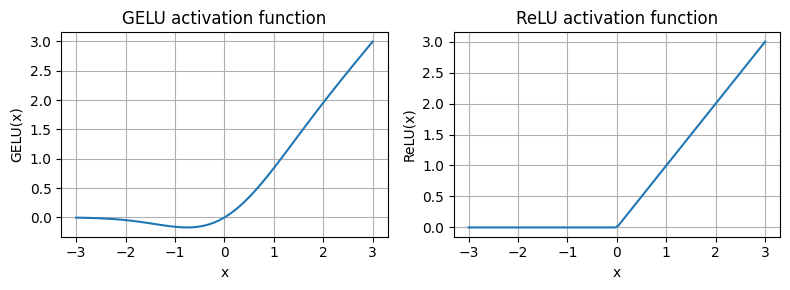

In [12]:
# GELU vs ReLU
import matplotlib.pyplot as plt
gelu, relu = GELU(), nn.ReLU()

x = torch.linspace(-3, 3, 100)
y_gelu, y_relu = gelu(x), relu(x)
plt.figure(figsize=(8, 3))
for i, (y, label) in enumerate(zip([y_gelu, y_relu], ["GELU", "ReLU"]), 1):
    plt.subplot(1, 2, i)
    plt.plot(x, y)
    plt.title(f"{label} activation function")
    plt.xlabel("x")
    plt.ylabel(f"{label}(x)")
    plt.grid(True)
plt.tight_layout()
plt.show()

Pretty much, the smoothness of GELU can lead to better optimization properties during training, as it allows for more nuance adjustments to the model's parameters.

Now let's use the GELU function to impelment a small neural network module that will be used in the transformer block later.

In [13]:
class FeedForward(nn.Module):
    def __init__(self, cfg):
        super().__init__()
        # 2 linear layers, the input and output dimensions of the nn are the same
        self.layers = nn.Sequential(
            nn.Linear(cfg["emb_dim"], 4 * cfg["emb_dim"]), # Expands input tiems 4
            GELU(),
            nn.Linear(4 * cfg["emb_dim"], cfg["emb_dim"]), # Reduces output back to orignal size(/ 4)
         )

    def forward(self, x):
        return self.layers(x)

In [14]:
ffn = FeedForward(GPT_CONFIG_124M)
x = torch.rand(2, 3, 768)
out = ffn(x)
print(out.shape)

torch.Size([2, 3, 768])


## Adding shortcut connections

Shortcut connections(skip or residual connections) allow gradients to skip 1+ layers by adding the output of one layer to the output of a later layer.  This solves the problem of gradients becoming progressively smaller as they propagate backward through the layers.

In [15]:
class ExampleDeepNeuralNetwork(nn.Module):
    def __init__(self, layer_sizes, use_shortcut):
        super().__init__()
        self.use_shortcut = use_shortcut
        # 5 layers
        self.layers = nn.ModuleList([
            nn.Sequential(nn.Linear(layer_sizes[0], layer_sizes[1]),
                          GELU()),
            nn.Sequential(nn.Linear(layer_sizes[1], layer_sizes[2]),
                          GELU()),
            nn.Sequential(nn.Linear(layer_sizes[2], layer_sizes[3]),
                          GELU()),
            nn.Sequential(nn.Linear(layer_sizes[3], layer_sizes[4]),
                          GELU()),
            nn.Sequential(nn.Linear(layer_sizes[4], layer_sizes[5]),
                          GELU())
        ])

    def forward(self, x):
        for layer in self.layers:
            layer_output = layer(x) # compute output of the current layer
            if self.use_shortcut and x.shape == layer_output.shape: # Check if shortcut can be applied
                x = x+layer_output
            else:
                x = layer_output
        return x

In [16]:
layer_sizes = [3, 3, 3, 3, 3, 1]
sample_input = torch.tensor([[1., 0., -1.]])
torch.manual_seed(123)
# Model without skip connections
model_without_shortcut = ExampleDeepNeuralNetwork(
    layer_sizes, use_shortcut=False
)

In [17]:
# Function to compute gradients in backward pass, to visualize effect of skip connections
def print_gradients(model, x):
    output = model(x) # Forward pass
    target = torch.tensor([[0.]])

    loss = nn.MSELoss()
    loss = loss(output, target) # Loss based on how close target and output are

    loss.backward() # Backward pass to calculate the gradients

    for name, param in model.named_parameters():
        if 'weight' in name:
            print(f"{name} has gradient mean of {param.grad.abs().mean().item()}")

In [18]:
print_gradients(model_without_shortcut, sample_input)

layers.0.0.weight has gradient mean of 0.00020173587836325169
layers.1.0.weight has gradient mean of 0.0001201116101583466
layers.2.0.weight has gradient mean of 0.0007152041071094573
layers.3.0.weight has gradient mean of 0.0013988735154271126
layers.4.0.weight has gradient mean of 0.005049645435065031


This shows the vanishing gradient problem.

In [19]:
torch.manual_seed(123)
model_with_shortcut = ExampleDeepNeuralNetwork(
    layer_sizes, use_shortcut=True
)
print_gradients(model_with_shortcut, sample_input)

layers.0.0.weight has gradient mean of 0.22169791162014008
layers.1.0.weight has gradient mean of 0.20694106817245483
layers.2.0.weight has gradient mean of 0.32896995544433594
layers.3.0.weight has gradient mean of 0.2665732204914093
layers.4.0.weight has gradient mean of 1.3258540630340576


### Connecting attention and linear layers in a transformer block

Combines multi-head attention, layer normalization, dropout, feed forward layers, and GELU activations.

In [20]:
import import_ipynb
from ch03 import MultiHeadAttention

class TransformerBlock(nn.Module):
    def __init__(self, cfg):
        super().__init__()
        self.att = MultiHeadAttention(
            d_in=cfg["emb_dim"],
            d_out=cfg["emb_dim"],
            context_length=cfg["context_length"],
            num_heads=cfg["n_heads"],
            dropout=cfg["drop_rate"],
            qkv_bias=cfg["qkv_bias"])
        self.ff = FeedForward(cfg)
        self.norm1 = LayerNorm(cfg["emb_dim"])
        self.norm2 = LayerNorm(cfg["emb_dim"])
        self.drop_shortcut = nn.Dropout(cfg["drop_rate"])

    def forward(self, x):
        # Shortcut connection for attention block
        shortcut = x
        x = self.norm1(x)
        x = self.att(x)
        x = self.drop_shortcut(x)
        x = x + shortcut # Add original input back

        # Shortcut connection for feed forward block
        shortcut = x
        x = self.norm2(x)
        x = self.ff(x)
        x = self.drop_shortcut(x)
        x = x + shortcut # Add original input back
        return x

tensor([0.9544, 1.4950, 1.4754, 0.8434, 0.7070, 1.0865])
Attention weights: tensor([0.1455, 0.2278, 0.2249, 0.1285, 0.1077, 0.1656])
Sum: tensor(1.0000)
Attention weights: tensor([0.1385, 0.2379, 0.2333, 0.1240, 0.1082, 0.1581])
Sum: tensor(1.)
Attention weights: tensor([0.1385, 0.2379, 0.2333, 0.1240, 0.1082, 0.1581])
Sum: tensor(1.)
tensor([0.4419, 0.6515, 0.5683])
tensor([[0.9995, 0.9544, 0.9422, 0.4753, 0.4576, 0.6310],
        [0.9544, 1.4950, 1.4754, 0.8434, 0.7070, 1.0865],
        [0.9422, 1.4754, 1.4570, 0.8296, 0.7154, 1.0605],
        [0.4753, 0.8434, 0.8296, 0.4937, 0.3474, 0.6565],
        [0.4576, 0.7070, 0.7154, 0.3474, 0.6654, 0.2935],
        [0.6310, 1.0865, 1.0605, 0.6565, 0.2935, 0.9450]])
tensor([[0.9995, 0.9544, 0.9422, 0.4753, 0.4576, 0.6310],
        [0.9544, 1.4950, 1.4754, 0.8434, 0.7070, 1.0865],
        [0.9422, 1.4754, 1.4570, 0.8296, 0.7154, 1.0605],
        [0.4753, 0.8434, 0.8296, 0.4937, 0.3474, 0.6565],
        [0.4576, 0.7070, 0.7154, 0.3474, 0.6654, 

In [21]:
torch.manual_seed(123)
x = torch.rand(2, 4, 768) # Creates sample input of shape [batch_size, num_tokens, emb_dim]
block = TransformerBlock(GPT_CONFIG_124M)
output = block(x)

# Verify the input dimensions are maintained in the output
print("Input shape:", x.shape)
print("Output shape:", output.shape)

Input shape: torch.Size([2, 4, 768])
Output shape: torch.Size([2, 4, 768])


## Coding the GPT model

In [22]:
class GPTModel(nn.Module):
    # Initializes token and positional embedding layers
    # Creates sequential stack of TransformerBlock modules
    # Applies LayerNorm layer
    # Linear output head defined to project the output into vocab space of tokenizer(create logits for each token)
    def __init__(self, cfg):
        super().__init__()
        self.tok_emb = nn.Embedding(cfg["vocab_size"], cfg["emb_dim"])
        self.pos_emb = nn.Embedding(cfg["context_length"], cfg["emb_dim"])
        self.drop_emb = nn.Dropout(cfg["drop_rate"])

        # Use implemented TransformerBlock
        self.trf_blocks = nn.Sequential(
            *[TransformerBlock(cfg)
              for _ in range(cfg["n_layers"])]
        )

        # Use implemented LayerNorm
        self.final_norm = LayerNorm(cfg["emb_dim"])
        self.out_head = nn.Linear(
            cfg["emb_dim"], cfg["vocab_size"], bias=False
        )

    # data flow through model
    # Takes batch of input token indeces, computes their embeddings, applies positional embeddings
    # Passes sequences through transformer blocks, normalizes output
    # Computes logits representing next token's probabilities
    def forward(self, in_idx):
        # Create embeddings
        batch_size, seq_len = in_idx.shape
        tok_embeds = self.tok_emb(in_idx)
        pos_embeds = self.pos_emb(
            torch.arange(seq_len, device=in_idx.device)
        )
        x = tok_embeds + pos_embeds
        x = self.drop_emb(x) # Apply dropout
        x = self.trf_blocks(x) # Create transformer blocks
        x = self.final_norm(x) # Final layer normalization
        logits = self.out_head(x) # Output layer
        return logits

In [23]:
torch.manual_seed(123)
model = GPTModel(GPT_CONFIG_124M)

out = model(batch) # Call this instead of forward, uses PyTorch '__call__'
print("Input batch:\n", batch)
print("\nOutput shape:", out.shape)
print(out)

Input batch:
 tensor([[6109, 3626, 6100,  345],
        [6109, 1110, 6622,  257]])

Output shape: torch.Size([2, 4, 50257])
tensor([[[ 0.3613,  0.4223, -0.0711,  ...,  0.3483,  0.4661, -0.2838],
         [-0.1792, -0.5660, -0.9485,  ...,  0.0477,  0.5181, -0.3168],
         [ 0.7120,  0.0332,  0.1085,  ...,  0.1018, -0.4327, -0.2553],
         [-1.0076,  0.3418, -0.1190,  ...,  0.7195,  0.4023,  0.0532]],

        [[-0.2564,  0.0900,  0.0335,  ...,  0.2659,  0.4454, -0.6806],
         [ 0.1230,  0.3653, -0.2074,  ...,  0.7705,  0.2710,  0.2246],
         [ 1.0558,  1.0318, -0.2800,  ...,  0.6936,  0.3205, -0.3178],
         [-0.1565,  0.3926,  0.3288,  ...,  1.2630, -0.1858,  0.0388]]],
       grad_fn=<UnsafeViewBackward0>)


In [24]:
total_params = sum(p.numel() for p in model.parameters())
print(f"Total number of parameters: {total_params:,}")

Total number of parameters: 163,009,536


In [25]:
print("Token embedding layer shape:", model.tok_emb.weight.shape)
print("Output layer shape:", model.out_head.weight.shape)

Token embedding layer shape: torch.Size([50257, 768])
Output layer shape: torch.Size([50257, 768])


In [26]:
total_params_gpt2 = (
    total_params - sum(p.numel()
    for p in model.out_head.parameters())
)
print(f"Number of trainable parameters "
    f"considering weight tying: {total_params_gpt2:,}"
)

Number of trainable parameters considering weight tying: 124,412,160


In [27]:
total_size_bytes = total_params * 4
total_size_mb = total_size_bytes / (1024 * 1024)
print(f"Total size of the model: {total_size_mb:.2f} MB")

Total size of the model: 621.83 MB


Shows the large storage capacity require for even small LLMs.

In [28]:
# Calculating total parameters in the feedforward and attention modules
block = TransformerBlock(GPT_CONFIG_124M)

total_params = sum(p.numel() for p in block.ff.parameters())
print(f"Total number of parameters in feed forward module: {total_params:,}")

total_params = sum(p.numel() for p in block.att.parameters())
print(f"Total number of parameters in attention module: {total_params:,}")

Total number of parameters in feed forward module: 4,722,432
Total number of parameters in attention module: 2,360,064


### Exercise 3.2 Initializing larger GPT models

We initialized a 124-million-parameter GPT model, which is known as “GPT-2 small.”
Without making any code modifications besides updating the configuration file, use
the GPTModel class to implement GPT-2 medium (using 1,024-dimensional embed-
dings, 24 transformer blocks, 16 multi-head attention heads), GPT-2 large (1,280-
dimensional embeddings, 36 transformer blocks, 20 multi-head attention heads),
and GPT-2 XL (1,600-dimensional embeddings, 48 transformer blocks, 25 multi-head
attention heads). As a bonus, calculate the total number of parameters in each GPT
model.

In [29]:
GPT_CONFIG_MEDIUM = {
    "vocab_size": 50257,
    "context_length": 1024, # Max number of input tokens the model can handle via the positional embeddings
    "emb_dim": 1024, # embedding size
    "n_heads": 16, # number of attention heads
    "n_layers": 24, # Number of transformer blocks
    "drop_rate": 0.1, # Dropout rate, to prevent overfitting
    "qkv_bias": False
}

In [30]:
torch.manual_seed(123)
model_medium = GPTModel(GPT_CONFIG_MEDIUM)

out = model_medium(batch) # Call this instead of forward, uses PyTorch '__call__'
print("Input batch:\n", batch)
print("\nOutput shape:", out.shape)
print(out)

Input batch:
 tensor([[6109, 3626, 6100,  345],
        [6109, 1110, 6622,  257]])

Output shape: torch.Size([2, 4, 50257])
tensor([[[ 0.5553,  0.4949,  0.3092,  ..., -0.2539, -0.3032,  0.2971],
         [ 0.3024, -0.0328, -0.5984,  ..., -0.6252, -0.5445, -0.9409],
         [ 0.4388,  0.3456, -0.2936,  ...,  0.5144,  0.0907,  0.0242],
         [ 0.1325,  0.6145, -0.8940,  ...,  0.3889,  0.0279, -0.5072]],

        [[ 1.0220,  0.3779,  0.8361,  ...,  0.1372, -0.2403,  0.8152],
         [ 0.0192,  0.3544, -0.5428,  ..., -0.0214,  0.0261, -0.4027],
         [ 0.2641,  0.1448, -0.3102,  ..., -0.0764, -0.4402,  0.2604],
         [ 0.6284,  1.2054, -0.6994,  ...,  0.0841, -0.3732, -0.1643]]],
       grad_fn=<UnsafeViewBackward0>)


In [31]:
total_params = sum(p.numel() for p in model_medium.parameters())
print(f"Total number of parameters: {total_params:,}")

Total number of parameters: 406,212,608


In [32]:
print("Token embedding layer shape:", model_medium.tok_emb.weight.shape)
print("Output layer shape:", model_medium.out_head.weight.shape)

Token embedding layer shape: torch.Size([50257, 1024])
Output layer shape: torch.Size([50257, 1024])


In [33]:
total_params_gpt2_medium = (
    total_params - sum(p.numel()
    for p in model_medium.out_head.parameters())
)
print(f"Number of trainable parameters "
    f"considering weight tying: {total_params_gpt2_medium:,}"
)

Number of trainable parameters considering weight tying: 354,749,440


In [34]:
total_size_bytes = total_params * 4
total_size_mb = total_size_bytes / (1024 * 1024)
print(f"Total size of the model: {total_size_mb:.2f} MB")

Total size of the model: 1549.58 MB


In [35]:
GPT_CONFIG_LARGE = {
    "vocab_size": 50257,
    "context_length": 1024, # Max number of input tokens the model can handle via the positional embeddings
    "emb_dim": 1280, # embedding size
    "n_heads": 20, # number of attention heads
    "n_layers": 36, # Number of transformer blocks
    "drop_rate": 0.1, # Dropout rate, to prevent overfitting
    "qkv_bias": False
}

In [36]:
torch.manual_seed(123)
model_large = GPTModel(GPT_CONFIG_LARGE)

out = model_large(batch) # Call this instead of forward, uses PyTorch '__call__'
print("Input batch:\n", batch)
print("\nOutput shape:", out.shape)
print(out)

Input batch:
 tensor([[6109, 3626, 6100,  345],
        [6109, 1110, 6622,  257]])

Output shape: torch.Size([2, 4, 50257])
tensor([[[-0.1292, -0.3847,  0.2248,  ...,  0.5369,  0.3691, -0.7619],
         [ 0.4239,  0.2338, -1.0530,  ..., -0.0855, -0.6005, -0.4725],
         [ 0.2074, -0.6801, -0.0454,  ..., -1.2456, -0.8294, -0.0187],
         [ 0.4618, -0.2833, -0.4043,  ...,  0.0392, -0.5204, -0.2321]],

        [[-0.6438,  0.1008,  0.2805,  ...,  0.5632,  0.7455, -0.3469],
         [ 0.5257, -0.0004, -0.1389,  ..., -0.3714,  0.3727,  0.1004],
         [ 0.3873, -0.7259, -0.1061,  ..., -1.1120, -0.4745,  0.2956],
         [ 0.2372, -0.0430,  0.1782,  ..., -0.4974, -0.2305,  0.2401]]],
       grad_fn=<UnsafeViewBackward0>)


In [37]:
total_params = sum(p.numel() for p in model_large.parameters())
print(f"Total number of parameters: {total_params:,}")

Total number of parameters: 838,220,800


In [38]:
print("Token embedding layer shape:", model_large.tok_emb.weight.shape)
print("Output layer shape:", model_large.out_head.weight.shape)

Token embedding layer shape: torch.Size([50257, 1280])
Output layer shape: torch.Size([50257, 1280])


In [39]:
total_params_gpt2_large = (
    total_params - sum(p.numel()
    for p in model_large.out_head.parameters())
)
print(f"Number of trainable parameters "
    f"considering weight tying: {total_params_gpt2_large:,}"
)

Number of trainable parameters considering weight tying: 773,891,840


In [40]:
total_size_bytes = total_params * 4
total_size_mb = total_size_bytes / (1024 * 1024)
print(f"Total size of the model: {total_size_mb:.2f} MB")

Total size of the model: 3197.56 MB


## Generating text

In [41]:
# idx is a (batch, n_tokens) array of indices
def generate_text_simple(model, idx,
                         max_new_tokens, context_size):
    for _ in range(max_new_tokens):
        idx_cond = idx[:, -context_size:] # Crops current context if it exceeds supported context size
        with torch.no_grad():
            logits = model(idx_cond)

        logits = logits[:, -1, :] # Last time step (batch, n_token, voacb_size) => (batch, vocab_size)
        probas = torch.softmax(logits, dim=-1) # probas has shape (batch, vocab_size), technically dont need to convert to prob. dist.
        idx_next = torch.argmax(probas, dim=-1, keepdim=True) # idx_next has shape (batch, 1) : index with highest prob
        idx = torch.cat((idx, idx_next), dim=1) # Append index to running sequence

    return idx

In [42]:
start_context = "Hello, I am"
encoded = tokenizer.encode(start_context)
print("encoded:", encoded)
encoded_tensor = torch.tensor(encoded).unsqueeze(0) # Adds batch dimension
print("encoded_tensor.shape:", encoded_tensor.shape)

encoded: [15496, 11, 314, 716]
encoded_tensor.shape: torch.Size([1, 4])


In [43]:
model.eval() # .eval disables random components like dropout which are only used during training
out = generate_text_simple(
    model=model,
    idx=encoded_tensor,
    max_new_tokens=6,
    context_size=GPT_CONFIG_124M["context_length"]
)
print("Output:", out)
print("Output length:", len(out[0]))

Output: tensor([[15496,    11,   314,   716, 27018, 24086, 47843, 30961, 42348,  7267]])
Output length: 10


In [44]:
decoded_text = tokenizer.decode(out.squeeze(0).tolist())
print(decoded_text)

Hello, I am Featureiman Byeswickattribute argue


Output text is gibberish because the model is not trained yet.  Currently only has random initial weights.